# **Assignment 1**

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    learning_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import matplotlib.pyplot as plt

In [2]:
#Load Dataset
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df["Average"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)/3

df["Result"] = np.where(df["Average"] >= 40, 1, 0)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Average,Result
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,1
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,1
4,male,group C,some college,standard,none,76,78,75,76.333333,1


In [4]:
X = df.drop(["Average","Result"], axis=1)
y = df["Result"]

In [5]:
categorical_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Logistic regression
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [11]:
# Decision tree
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

In [10]:
# Random Forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [13]:
# Compare Accuracy, Precision, Recall and F1 Score
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf)
    ],
    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf)
    ],
    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf)
    ],
    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     1.000   1.000000     1.0  1.000000
1        Decision Tree     0.995   0.994764     1.0  0.997375
2        Random Forest     1.000   1.000000     1.0  1.000000


In [14]:
print("Logistic Regression")
print(classification_report(y_test,y_pred_lr))

print("Decision Tree")
print(classification_report(y_test,y_pred_dt))

print("Random Forest")
print(classification_report(y_test,y_pred_rf))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00       190

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Decision Tree
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.99      1.00      1.00       190

    accuracy                           0.99       200
   macro avg       1.00      0.95      0.97       200
weighted avg       1.00      0.99      0.99       200

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00       190

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00   

##### 5-Fold Cross Validation

In [16]:
# Logistic Regression
scores_lr = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores_lr)
print("Average:",scores_lr.mean())

[0.995 1.    1.    1.    0.995]
Average: 0.998


In [17]:
# Decision Tree
scores_dt = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores_dt)
print("Average:",scores_dt.mean())

[0.98  0.99  1.    0.985 0.99 ]
Average: 0.9889999999999999


In [18]:
# Random Forest
scores_rf = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores_rf)
print("Average:",scores_rf.mean())

[0.99  0.995 1.    0.995 0.995]
Average: 0.9949999999999999


In [19]:
# Tune decision tree hyperparameters
param_grid_dt = {
    "model__criterion":["gini","entropy"],
    "model__max_depth":[3,5,10,None],
    "model__min_samples_split":[2,5,10]
}

grid_dt = GridSearchCV(
    dt_pipeline,
    param_grid_dt,
    cv=5,
    scoring="accuracy"
)

grid_dt.fit(X_train,y_train)

print("Best Parameters")
print(grid_dt.best_params_)

print("Best Accuracy")
print(grid_dt.best_score_)

Best Parameters
{'model__criterion': 'entropy', 'model__max_depth': 3, 'model__min_samples_split': 2}
Best Accuracy
0.9925


In [21]:
# Tune Random Forest hyperparameters
param_grid_rf = {
    "model__n_estimators":[100,200],
    "model__max_depth":[None,5,10],
    "model__min_samples_split":[2,5],
    "model__criterion":["gini","entropy"]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring="accuracy"
)

grid_rf.fit(X_train,y_train)

print("Best Parameters")
print(grid_rf.best_params_)

print("Best Accuracy")
print(grid_rf.best_score_)

Best Parameters
{'model__criterion': 'gini', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best Accuracy
0.9925


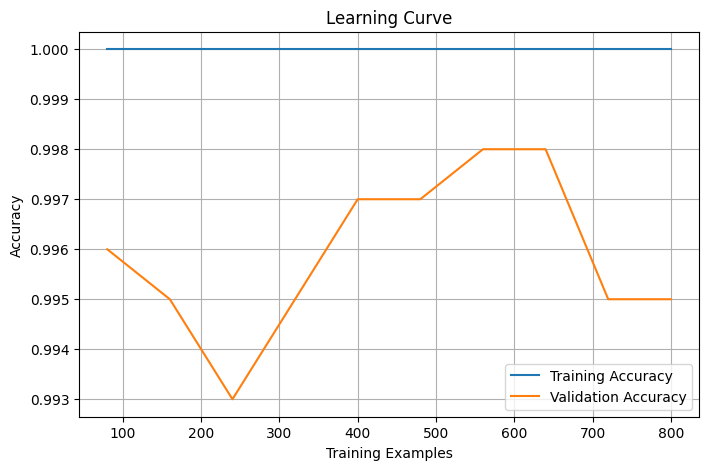

In [22]:
# Plot learning curve
train_sizes, train_scores, test_scores = learning_curve(
    grid_rf.best_estimator_,
    X,
    y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1,1.0,10)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.xlabel("Training Examples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

##### Which model performed best and why ?

Random Forest generally performs the best because it combines multiple decision trees, reducing overfitting and improving generalization

#**Assignment - 2**

In [24]:
# Initial Analysis
df = pd.read_csv("Loan prediction.csv")

print("First 10 Records:")
print(df.head(10))

First 10 Records:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2        

In [25]:
print("\nFeatures in the Dataset:")

features = df.drop("Loan_Status", axis=1).columns
print(features)

print("\nTarget Variable:")
print(df["Loan_Status"].name)


Features in the Dataset:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

Target Variable:
Loan_Status


In [26]:
print("\nDataset Shape:")
print(df.shape)

print("\nNumber of Records (Rows):", df.shape[0])
print("Number of Attributes (Columns):", df.shape[1])


Dataset Shape:
(614, 13)

Number of Records (Rows): 614
Number of Attributes (Columns): 13


In [27]:
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())


Missing Values in Each Column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total Missing Values: 149


In [28]:
print("\nStatistical Summary of Numerical Columns:")
print(df.describe())


Statistical Summary of Numerical Columns:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


In [32]:
# Data Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [30]:
categorical_columns = X.select_dtypes(include="object").columns

numerical_columns = X.select_dtypes(exclude="object").columns

print("\nCategorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)


Categorical Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area'],
      dtype='object')

Numerical Columns:
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


In [33]:
num_imputer = SimpleImputer(strategy="median")

X[numerical_columns] = num_imputer.fit_transform(X[numerical_columns])

In [34]:
cat_imputer = SimpleImputer(strategy="most_frequent")

X[categorical_columns] = cat_imputer.fit_transform(X[categorical_columns])

In [35]:
print("\nMissing Values After Imputation:")
print(X.isnull().sum())


Missing Values After Imputation:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


In [36]:
encoder = OneHotEncoder(drop="first",
                        sparse_output=False,
                        handle_unknown="ignore")

encoded_data = encoder.fit_transform(X[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)

In [37]:
X = X.drop(categorical_columns, axis=1)

X = pd.concat([X.reset_index(drop=True),
               encoded_df.reset_index(drop=True)],
               axis=1)

In [39]:
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

y = y.map({
    "N":0,
    "Y":1
})

In [41]:
print("\nFinal Feature Matrix (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)


Final Feature Matrix (X):
   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0         0.072991          -0.554487   -0.211241          0.273231   
1        -0.134412          -0.038732   -0.211241          0.273231   
2        -0.393747          -0.554487   -0.948996          0.273231   
3        -0.462062           0.251980   -0.306435          0.273231   
4         0.097728          -0.554487   -0.056551          0.273231   

   Credit_History  Loan_ID_LP001003  Loan_ID_LP001005  Loan_ID_LP001006  \
0        0.411733               0.0               0.0               0.0   
1        0.411733               1.0               0.0               0.0   
2        0.411733               0.0               1.0               0.0   
3        0.411733               0.0               0.0               1.0   
4        0.411733               0.0               0.0               0.0   

   Loan_ID_LP001008  Loan_ID_LP001011  ...  Loan_ID_LP002990  Gender_Male  \
0               0.

### Exploratory Data Analysis

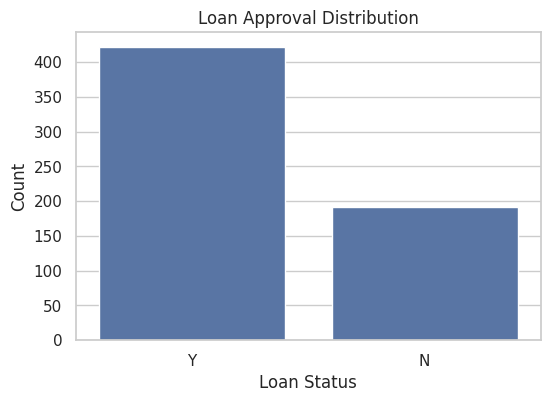

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()

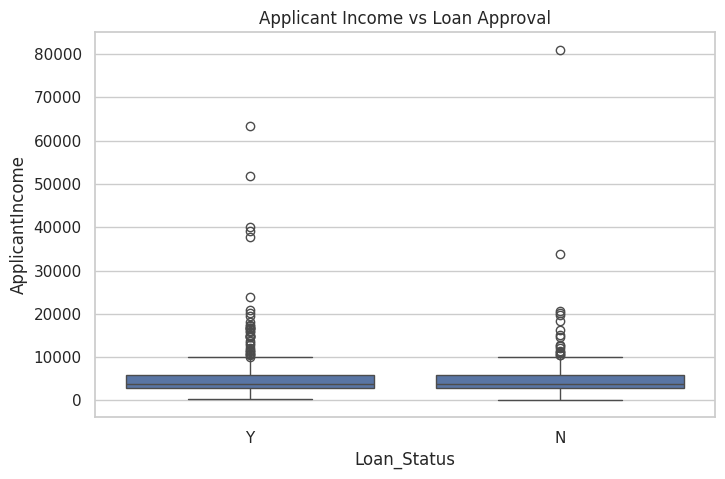

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Loan_Status',
            y='ApplicantIncome',
            data=df)

plt.title("Applicant Income vs Loan Approval")

plt.show()

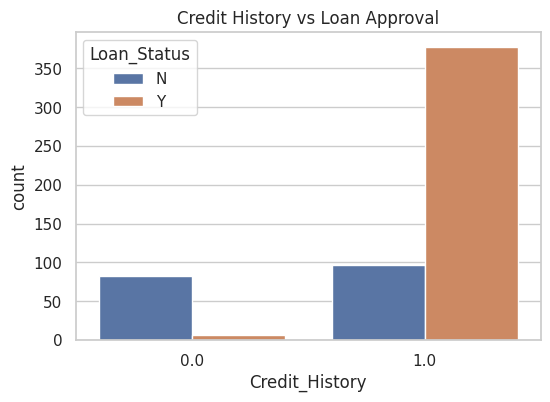

In [44]:
plt.figure(figsize=(6,4))

sns.countplot(x='Credit_History',
              hue='Loan_Status',
              data=df)

plt.title("Credit History vs Loan Approval")

plt.show()


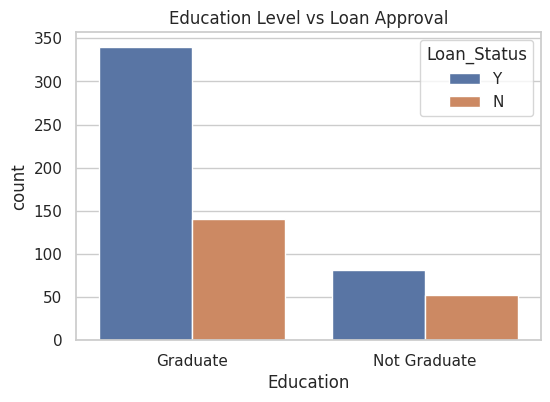

In [45]:
plt.figure(figsize=(6,4))

sns.countplot(x='Education',
              hue='Loan_Status',
              data=df)

plt.title("Education Level vs Loan Approval")

plt.show()

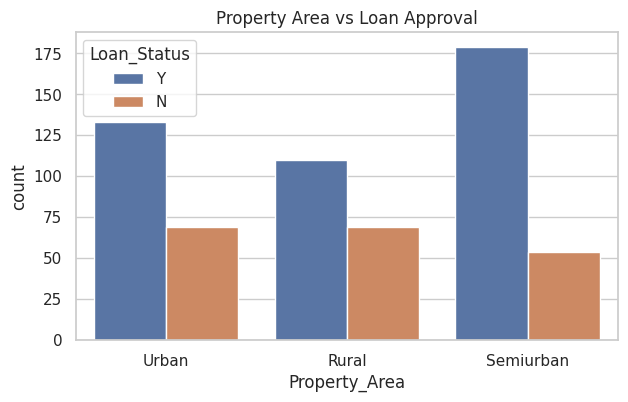

In [46]:
plt.figure(figsize=(7,4))

sns.countplot(x='Property_Area',
              hue='Loan_Status',
              data=df)

plt.title("Property Area vs Loan Approval")

plt.show()

### Split the dataset into training and testing sets (80:20).

In [47]:
for column in df.columns:

    if df[column].dtype == 'object':
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

/tmp/ipykernel_5475/568560686.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
/tmp/ipykernel_5475/568560686.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [49]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop("Loan_Status_Y", axis=1)

y = df["Loan_Status_Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape  :", X_test.shape)

Training Data Shape : (491, 627)
Testing Data Shape  : (123, 627)


In [52]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [51]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [53]:
# Random Forest
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [54]:
def evaluate_model(y_test, prediction):

    accuracy = accuracy_score(y_test, prediction)

    precision = precision_score(y_test, prediction)

    recall = recall_score(y_test, prediction)

    f1 = f1_score(y_test, prediction)

    return accuracy, precision, recall, f1

In [55]:
lr_result = evaluate_model(y_test, lr_pred)

dt_result = evaluate_model(y_test, dt_pred)

rf_result = evaluate_model(y_test, rf_pred)

In [56]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        lr_result[0],
        dt_result[0],
        rf_result[0]
    ],

    "Precision":[
        lr_result[1],
        dt_result[1],
        rf_result[1]
    ],

    "Recall":[
        lr_result[2],
        dt_result[2],
        rf_result[2]
    ],

    "F1 Score":[
        lr_result[3],
        dt_result[3],
        rf_result[3]
    ]

})

print("\nModel Comparison")
print(results)


Model Comparison
                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression  0.788618   0.759615  0.9875  0.858696
1        Decision Tree  0.682927   0.725275  0.8250  0.771930
2        Random Forest  0.788618   0.759615  0.9875  0.858696


In [58]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("\nBest Performing Model")
print("----------------------")
print("Model :", best_model["Model"])
print("Accuracy :", round(best_model["Accuracy"],4))
print("Precision :", round(best_model["Precision"],4))
print("Recall :", round(best_model["Recall"],4))
print("F1 Score :", round(best_model["F1 Score"],4))


Best Performing Model
----------------------
Model : Logistic Regression
Accuracy : 0.7886
Precision : 0.7596
Recall : 0.9875
F1 Score : 0.8587


In [60]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [61]:
for column in df.columns:

    if df[column].dtype == "object":
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        df[column].fillna(df[column].median(), inplace=True)

/tmp/ipykernel_5475/1467578527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(), inplace=True)
/tmp/ipykernel_5475/1467578527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [62]:
df = pd.get_dummies(df, drop_first=True)

In [63]:
X = df.drop("Loan_Status_Y", axis=1)
y = df["Loan_Status_Y"]

In [64]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [65]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}


In [68]:
results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="accuracy"
    )

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("Fold Accuracies:")
    for i, score in enumerate(scores):
        print(f"Fold {i+1}: {score:.4f}")

    print("Mean Accuracy :", scores.mean())
    print("Standard Deviation :", scores.std())

    results.append([
        name,
        scores[0],
        scores[1],
        scores[2],
        scores[3],
        scores[4],
        scores.mean(),
        scores.std()
    ])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


Logistic Regression
Fold Accuracies:
Fold 1: 0.8211
Fold 2: 0.8130
Fold 3: 0.8049
Fold 4: 0.7561
Fold 5: 0.8279
Mean Accuracy : 0.8045981607357058
Standard Deviation : 0.025448821062939588

Decision Tree
Fold Accuracies:
Fold 1: 0.7967
Fold 2: 0.7642
Fold 3: 0.7805
Fold 4: 0.7236
Fold 5: 0.7705
Mean Accuracy : 0.7671064907370386
Standard Deviation : 0.024381225805396558

Random Forest
Fold Accuracies:
Fold 1: 0.8130
Fold 2: 0.8211
Fold 3: 0.8049
Fold 4: 0.7724
Fold 5: 0.8197
Mean Accuracy : 0.8062108489937359
Standard Deviation : 0.0178776159045629


In [69]:
cv_results = pd.DataFrame(results, columns=[
    "Model",
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
    "Mean Accuracy",
    "Std Deviation"
])

print("\nCross Validation Results")
print(cv_results)


Cross Validation Results
                 Model    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
0  Logistic Regression  0.821138  0.813008  0.804878  0.756098  0.827869   
1        Decision Tree  0.796748  0.764228  0.780488  0.723577  0.770492   
2        Random Forest  0.813008  0.821138  0.804878  0.772358  0.819672   

   Mean Accuracy  Std Deviation  
0       0.804598       0.025449  
1       0.767106       0.024381  
2       0.806211       0.017878  


In [70]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

before_prediction = rf.predict(X_test)

before_accuracy = accuracy_score(y_test, before_prediction)

print("Accuracy Before Tuning :", before_accuracy)

Accuracy Before Tuning : 0.7886178861788617


In [74]:
parameter_grid = {

    "n_estimators": [50, 100, 200],

    "max_depth": [3, 5, 10],

    "min_samples_split": [2, 5, 10]

}

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(random_state=42),

    param_grid=parameter_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [75]:
print("\nBest Parameters")
print(grid_search.best_params_)

print("\nBest Cross Validation Score")
print(grid_search.best_score_)


Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score
0.7474335188620902


In [76]:
best_model = grid_search.best_estimator_

after_prediction = best_model.predict(X_test)

accuracy = accuracy_score(y_test, after_prediction)
precision = precision_score(y_test, after_prediction)
recall = recall_score(y_test, after_prediction)
f1 = f1_score(y_test, after_prediction)

print("\nPerformance After Tuning")

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)


Performance After Tuning
Accuracy : 0.7235772357723578
Precision : 0.7017543859649122
Recall : 1.0
F1 Score : 0.8247422680412371


In [77]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest (Before Tuning)",
        "Random Forest (After Tuning)"
    ],

    "Accuracy":[
        before_accuracy,
        accuracy
    ]

})

print("\nComparison")
print(comparison)


Comparison
                           Model  Accuracy
0  Random Forest (Before Tuning)  0.788618
1   Random Forest (After Tuning)  0.723577


In [78]:
depths = [2, 5, 15]

results = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    results.append([
        depth,
        train_accuracy,
        test_accuracy
    ])

In [79]:
comparison = pd.DataFrame(
    results,
    columns=[
        "Max Depth",
        "Training Accuracy",
        "Testing Accuracy"
    ]
)

print("\nDecision Tree Performance")
print(comparison)


Decision Tree Performance
   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.822811          0.788618
1          5           0.837067          0.756098
2         15           0.971487          0.691057


In [80]:
print("Analysis")

print("Depth = 2  : Underfitting (High Bias)")
print("Depth = 15 : Overfitting (High Variance)")
print("Depth = 5  : Best Bias-Variance Balance")

Analysis
Depth = 2  : Underfitting (High Bias)
Depth = 15 : Overfitting (High Variance)
Depth = 5  : Best Bias-Variance Balance
